# 📰 NLP Text Classification using Machine Learning

## 👨‍🎓 Student Details
- **Name:** Amit Ramchandra Mali  
- **PRN:** 202301070196  
- **Batch:** DL-3  

---

## 📌 Assignment Details
- **Lab Assignment 4:** NLP - Text Classification  

---

## 🔗 GitHub Repository
You can find the complete project here:  
👉 https://github.com/Amitmali72/News-classification-NLP-Text-Classification-Lab-Assignment-4  

---

## 📖 Description
This notebook demonstrates the implementation of Natural Language Processing (NLP) techniques for text classification.

The project uses the **AG News dataset**, which consists of news articles categorized into four classes: World, Sports, Business, and Sci/Tech. The text data is preprocessed using techniques such as tokenization, stopword removal, and lemmatization.

After preprocessing, the text is converted into numerical features using **TF-IDF vectorization**. Machine learning models such as **Naive Bayes** and **Support Vector Machine (SVM)** are then trained to classify the news articles.

The performance of the models is evaluated using accuracy, classification report, and confusion matrix.

---

## 🎯 Objectives
- Apply NLP preprocessing techniques  
- Convert text into numerical features using TF-IDF  
- Train machine learning models for classification  
- Evaluate model performance using standard metrics  

---

In [7]:
# importing all the modules required
import pandas as pd
import numpy as np
import re

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
# Importing dataset
df = pd.read_csv("train.csv")

df = df.sample(5000, random_state=42)   # keep it manageable
df.head()

,Class Index,Title,Description
71787,3,"BBC set for major shake-up, claims newspaper","London - The British Broadcasting Corporation,..."
67218,3,Marsh averts cash crunch,Embattled insurance broker #39;s banks agree t...
54066,2,"Jeter, Yankees Look to Take Control (AP)",AP - Derek Jeter turned a season that started ...
7168,4,Flying the Sun to Safety,When the Genesis capsule comes back to Earth w...
29618,3,Stocks Seen Flat as Nortel and Oil Weigh,NEW YORK (Reuters) - U.S. stocks were set to ...


In [4]:
df.rename(columns={"Class Index": "Class"}, inplace=True)

In [5]:
df['text'] = df['Title'] + " " + df['Description'] #
df = df[['text', 'Class']]
df.head()

,text,Class
71787,"BBC set for major shake-up, claims newspaper L...",3
67218,Marsh averts cash crunch Embattled insurance b...,3
54066,"Jeter, Yankees Look to Take Control (AP) AP - ...",2
7168,Flying the Sun to Safety When the Genesis caps...,4
29618,Stocks Seen Flat as Nortel and Oil Weigh NEW ...,3


In [8]:
#performing preprocessing for NLP

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower() # Text lowerized -lowercase
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    tokens = word_tokenize(text)# performed word tokenization

    tokens = [word for word in tokens if word not in stop_words] # Stop words Removed
    tokens = [lemmatizer.lemmatize(word) for word in tokens] # Lemmatization

    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text)
df.head()

,text,Class,clean_text
71787,"BBC set for major shake-up, claims newspaper L...",3,bbc set major shake claim newspaper london bri...
67218,Marsh averts cash crunch Embattled insurance b...,3,marsh averts cash crunch embattled insurance b...
54066,"Jeter, Yankees Look to Take Control (AP) AP - ...",2,jeter yankee look take control ap ap derek jet...
7168,Flying the Sun to Safety When the Genesis caps...,4,flying sun safety genesis capsule come back ea...
29618,Stocks Seen Flat as Nortel and Oil Weigh NEW ...,3,stock seen flat nortel oil weigh new york reut...


In [9]:
# Vectorization
cv = CountVectorizer()
X_cv = cv.fit_transform(df['clean_text'])

print("CountVectorizer shape:", X_cv.shape)

CountVectorizer shape: (5000, 15189)


In [10]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['clean_text'])

print("TF-IDF shape:", X.shape)

TF-IDF shape: (5000, 15189)


In [11]:
# Performing train-test split
y = df['Class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4000, 15189)
Test shape: (1000, 15189)


In [12]:
# Training the model using Naive-bayes classifier
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [13]:
# Predicting
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.887

Classification Report:
               precision    recall  f1-score   support

           1       0.91      0.89      0.90       241
           2       0.92      0.96      0.94       250
           3       0.85      0.88      0.86       257
           4       0.87      0.82      0.84       252

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



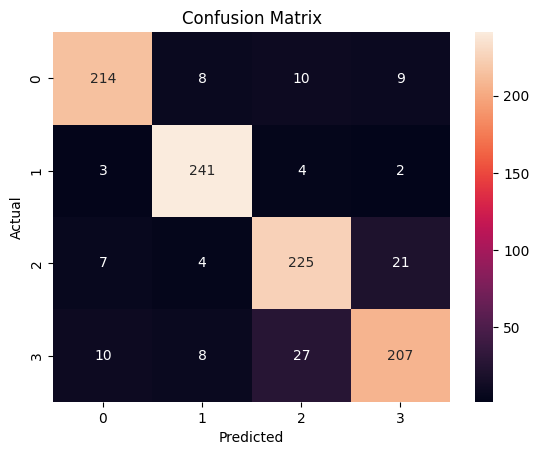

In [15]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
# We can try another classifier- SVM
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.881


In [17]:
# Comparison
print("\nModel Comparison:")
print("Naive Bayes:", accuracy_score(y_test, y_pred))
print("SVM:", accuracy_score(y_test, y_pred_svm))


Model Comparison:
Naive Bayes: 0.887
SVM: 0.881


###Conclusion
 ###### Naive Bayes performed slightly better than SVM in this case. This is expected because Naive Bayes works very well with text data and high-dimensional sparse features like TF-IDF. Added entire notebook in a Github repository with readme file